# Chunk-Level XGBoost — Random Slopes: Quantity, Weight, Cube + ShiftDuration Diagnostic

Tests random slopes on three physical task features (Quantity, Weight, Cube)
and one fatigue diagnostic (ShiftDuration) to find whether workers differ
in how those features affect their pick time.

**Deployment constraint:** at prediction time only product and location features
are available — no timestamps, no distance, no sequential features.
XGBoost is trained using only deployment-safe features.

**ShiftDuration is treated differently:**
It is used only in the mixed model estimation and slope distribution plot —
NOT as an XGBoost feature, since timestamps are not available at prediction time.
It is included purely as a diagnostic: does the rate at which workers fatigue
over their shift differ between workers?

**Models compared at chunk level per WorkCode (Quantity, Weight, Cube only):**
1. **Baseline** — no worker features
2. **+ Intercept** — random intercept only
3. **+ Intercept + Slope[Quantity]**
4. **+ Intercept + Slope[Weight]**
5. **+ Intercept + Slope[Cube]**

**ShiftDuration diagnostic (separate section at the end):**
Fits `Time_Delta_sec ~ ShiftDuration_z + (1 + ShiftDuration_z | UserID)` on
training data only. Plots the slope distribution to answer:
do workers differ in how much they slow down over their shift?

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH             = Path("~/Lucas_Systems_Capstone_Project/data/processed")
WAREHOUSE        = "OE"
WORKCODES        = ["10", "20", "30"]
MAX_TIME         = 300
BLOCK_SIZE       = 50
RANDOM_STATE     = 2026
# Hour excluded — not available at prediction time (no timestamps)
SLOPE_CANDIDATES = ["Quantity", "Weight", "Cube"]

# Features NOT available at prediction time — excluded from XGBoost feature set
# even though they exist in training data
NOT_AVAILABLE_AT_PREDICTION = [
    "Travel_Distance", "log_travel_distance",  # distance
    "same_aisle", "same_lockey", "diff_level", "same_location",  # sequential
    "time_of_day", "day_of_week", "hour", "Hour",  # time
]


## Helper Functions

In [29]:
def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=PATH / f"{warehouse.lower()}_detailed.parquet",
        warehouse=warehouse,
        max_time=max_time,
        work_code=str(workcode)
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    # ShiftDuration: hours since worker's first pick of the day
    # Computed from training timestamps — used only for the mixed model diagnostic,
    # NOT included in XGBoost features since timestamps aren't available at prediction time
    d = d.sort_values(["UserID", "date", "Timestamp"])
    d["shift_start"]    = d.groupby(["UserID", "date"])["Timestamp"].transform("min")
    d["ShiftDuration"]  = (
        (d["Timestamp"] - d["shift_start"]).dt.total_seconds() / 3600
    ).clip(lower=0)
    d = d.drop(columns=["shift_start"])

    # Strip all features not available at prediction time
    features = [
        f for f in features_all
        if f not in NOT_AVAILABLE_AT_PREDICTION
    ]
    cat_cols = [
        c for c in cat_cols_all
        if c not in NOT_AVAILABLE_AT_PREDICTION
    ]

    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days  = sorted(df["date"].dropna().unique())
    n_test    = max(1, int(round(len(all_days) * test_ratio)))
    test_days = all_days[-n_test:]
    train_df  = df[df["date"] < test_days[0]].copy()
    test_df   = df[df["date"].isin(test_days)].copy()
    return train_df, test_df


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def make_test_blocks(test_df, block_size=50):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks = []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.reset_index()
        for start in range(0, len(g) - block_size + 1, block_size):
            chunk = g.iloc[start:start + block_size]
            if len(chunk) == block_size:
                blocks.append({
                    "BlockID": f"{uid}_{day}_{start // block_size}",
                    "UserID":  uid,
                    "date":    day,
                    "indices": chunk["index"].tolist()
                })
    return blocks


def eval_blocks(blocks, actual_series, pred_series):
    actual_b = [actual_series.loc[b["indices"]].sum() for b in blocks]
    pred_b   = [pred_series.loc[b["indices"]].sum()   for b in blocks]
    return mean_absolute_error(actual_b, pred_b), r2_score(actual_b, pred_b)


## Random Effects Estimation Functions

In [30]:
def estimate_intercept_only(train_df):
    """Random intercept: Time_Delta_sec ~ 1 + (1|UserID)"""
    df_re = train_df[["UserID", "Time_Delta_sec"]].dropna().copy()
    if df_re["UserID"].nunique() < 2:
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_intercept": 0.0})

    result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    icc = result.cov_re.values[0][0] / (result.cov_re.values[0][0] + result.scale)
    print(f"    [Intercept] Grand mean: {result.fe_params['Intercept']:.1f}s | "
          f"Worker SD: {np.sqrt(result.cov_re.values[0][0]):.1f}s | ICC: {icc:.3f}")

    return pd.DataFrame({
        "UserID":           list(result.random_effects.keys()),
        "worker_intercept": [float(v.iloc[0]) for v in result.random_effects.values()]
    })


def estimate_random_slopes(train_df, slope_var):
    """
    Fits: Time_Delta_sec ~ slope_var_z + (1 + slope_var_z | UserID)
    The slope variable is standardised before fitting for convergence stability.
    Returns per-worker intercept AND slope.
    Falls back to intercept-only and slope=0 on convergence failure.
    Works for any slope_var in SLOPE_CANDIDATES including Hour.
    """
    slope_col = f"worker_slope_{slope_var.lower()}"
    df_re = train_df[["UserID", "Time_Delta_sec", slope_var]].dropna().copy()

    if df_re["UserID"].nunique() < 2:
        return pd.DataFrame({
            "UserID": df_re["UserID"].unique(),
            "worker_intercept": 0.0,
            slope_col: 0.0
        })

    mu = df_re[slope_var].mean()
    sd = df_re[slope_var].std() + 1e-8
    df_re["sv_z"] = (df_re[slope_var] - mu) / sd

    try:
        result = smf.mixedlm(
            "Time_Delta_sec ~ sv_z",
            data=df_re,
            groups=df_re["UserID"],
            exog_re=df_re[["sv_z"]]
        ).fit(reml=True, disp=False)

        rows = [{
            "UserID":           uid,
            "worker_intercept": float(re.iloc[0]),
            slope_col:          float(re.iloc[1]) if len(re) > 1 else 0.0
        } for uid, re in result.random_effects.items()]

        slope_sd = np.sqrt(max(result.cov_re.values[1][1], 0)) if result.cov_re.shape[0] > 1 else 0.0
        print(f"    [{slope_var} slope] Fixed effect: "
              f"{result.fe_params.get('sv_z', float('nan')):.3f}s per SD | "
              f"Slope SD across workers: {slope_sd:.3f}")

        return pd.DataFrame(rows)

    except Exception as e:
        print(f"    [{slope_var} slope] Failed ({e}) — using intercept only")
        fallback = estimate_intercept_only(train_df)
        fallback[slope_col] = 0.0
        return fallback

## Main Loop — Slope Candidates × WorkCodes

Outer loop: slope candidate (Quantity, Weight, Cube)  
Inner loop: WorkCode (10, 20, 30)  
Baseline and + Intercept are only run once per WorkCode to avoid redundancy.  

**All XGBoost features are restricted to those available at prediction time.**

In [31]:
all_results        = []
slope_dist_data    = {}   # (slope_var, wc) -> worker RE dataframe for distribution plots
recorded_baselines = set()  # avoid re-running baseline/intercept for each slope candidate

xgb_params = dict(
    n_estimators=800, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)

for slope_var in SLOPE_CANDIDATES:
    print(f"\n{'#'*60}")
    print(f"SLOPE CANDIDATE: {slope_var}")
    print(f"{'#'*60}")
    slope_col = f"worker_slope_{slope_var.lower()}"

    for wc in WORKCODES:
        print(f"\n  {'='*50}")
        print(f"  WorkCode {wc}")
        print(f"  {'='*50}")

        df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
        train_df, test_df = split_by_days(df_wc)
        print(f"  Train: {len(train_df)} | Test: {len(test_df)}")

        # Fit random slopes model (always returns intercept + slope columns)
        slopes_df = estimate_random_slopes(train_df, slope_var)
        slope_dist_data[(slope_var, wc)] = slopes_df

        # Merge worker features
        train_df = train_df.merge(slopes_df, on="UserID", how="left")
        test_df  = test_df.merge(slopes_df,  on="UserID", how="left")
        for col in ["worker_intercept", slope_col]:
            train_df[col] = train_df[col].fillna(0.0)
            test_df[col]  = test_df[col].fillna(0.0)

        train_df = train_df.reset_index(drop=True)
        test_df  = test_df.reset_index(drop=True)
        y_train  = train_df["Time_Delta_sec"].astype(float)
        y_test   = test_df["Time_Delta_sec"].astype(float)

        cats_clean  = [c for c in cat_cols  if c != "efficient_user"]
        feats_clean = [f for f in features  if f != "efficient_user"]

        scenarios = {
            "Baseline":                          feats_clean,
            "+ Intercept":                       feats_clean + ["worker_intercept"],
            f"+ Intercept + Slope[{slope_var}]": feats_clean + ["worker_intercept", slope_col],
        }

        blocks = make_test_blocks(test_df, block_size=BLOCK_SIZE)

        for label, feats in scenarios.items():
            # Only run Baseline and + Intercept once per WorkCode
            key = (wc, label)
            if label in ["Baseline", "+ Intercept"] and key in recorded_baselines:
                continue

            X_train, X_test = make_X(train_df, test_df, feats, cats_clean)
            model = XGBRegressor(**xgb_params)
            model.fit(X_train, y_train)
            preds = pd.Series(model.predict(X_test), index=test_df.index)

            mae, r2 = eval_blocks(blocks, y_test, preds)
            all_results.append({
                "SlopeCandidate": slope_var if "Slope" in label else "—",
                "WorkCode":       wc,
                "Model":          label,
                "n_blocks":       len(blocks),
                "mae_per_task":   round(mae / BLOCK_SIZE, 3),
                "r2":             round(r2, 4),
            })

            if label in ["Baseline", "+ Intercept"]:
                recorded_baselines.add(key)

results_df = pd.DataFrame(all_results)
print("\nDone.")


############################################################
SLOPE CANDIDATE: Quantity
############################################################

  WorkCode 10
  Train: 3599 | Test: 483
    [Quantity slope] Fixed effect: 6.254s per SD | Slope SD across workers: 0.000

  WorkCode 20
  Train: 18310 | Test: 3024
    [Quantity slope] Failed (Singular matrix) — using intercept only


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


    [Intercept] Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034

  WorkCode 30
  Train: 58434 | Test: 6864
    [Quantity slope] Fixed effect: 3.759s per SD | Slope SD across workers: 0.000

############################################################
SLOPE CANDIDATE: Weight
############################################################

  WorkCode 10
  Train: 3599 | Test: 483
    [Weight slope] Fixed effect: 3.937s per SD | Slope SD across workers: 0.000

  WorkCode 20
  Train: 18310 | Test: 3024


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


    [Weight slope] Fixed effect: 0.662s per SD | Slope SD across workers: 0.000

  WorkCode 30
  Train: 58434 | Test: 6864
    [Weight slope] Fixed effect: -0.562s per SD | Slope SD across workers: 0.000

############################################################
SLOPE CANDIDATE: Cube
############################################################

  WorkCode 10
  Train: 3599 | Test: 483
    [Cube slope] Fixed effect: 3.543s per SD | Slope SD across workers: 0.000

  WorkCode 20
  Train: 18310 | Test: 3024


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


    [Cube slope] Fixed effect: 2.621s per SD | Slope SD across workers: 0.000

  WorkCode 30
  Train: 58434 | Test: 6864
    [Cube slope] Fixed effect: -1.407s per SD | Slope SD across workers: 0.000

Done.


## Results Table

In [32]:
print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks\n")
display(
    results_df
    .sort_values(["WorkCode", "mae_per_task"])
    .reset_index(drop=True)
)

Warehouse: OE | Block size: 50 tasks



,SlopeCandidate,WorkCode,Model,n_blocks,mae_per_task,r2
0,Quantity,10,+ Intercept + Slope[Quantity],6,11.198,0.2890
1,Cube,10,+ Intercept + Slope[Cube],6,11.260,0.2805
2,Weight,10,+ Intercept + Slope[Weight],6,11.287,0.2859
3,—,10,+ Intercept,6,12.014,0.2352
4,—,10,Baseline,6,18.903,-0.6371
5,—,20,Baseline,55,7.201,0.5290
6,Quantity,20,+ Intercept + Slope[Quantity],55,10.476,-0.4229
7,Weight,20,+ Intercept + Slope[Weight],55,10.476,-0.4229
8,—,20,+ Intercept,55,10.832,-0.5573
9,Cube,20,+ Intercept + Slope[Cube],55,10.993,-0.7954


## Summary — Which Slope Candidate Wins per WorkCode?

In [33]:
summary_rows = []
for wc in WORKCODES:
    wc_df    = results_df[results_df["WorkCode"] == wc]
    mae_base = wc_df[wc_df["Model"] == "Baseline"]["mae_per_task"].values
    mae_int  = wc_df[wc_df["Model"] == "+ Intercept"]["mae_per_task"].values
    if len(mae_base) == 0:
        continue
    mae_base = mae_base[0]
    mae_int  = mae_int[0] if len(mae_int) > 0 else float("nan")

    for sv in SLOPE_CANDIDATES:
        label = f"+ Intercept + Slope[{sv}]"
        row   = wc_df[wc_df["Model"] == label]["mae_per_task"].values
        mae_s = row[0] if len(row) > 0 else float("nan")
        summary_rows.append({
            "WorkCode":                  wc,
            "Slope":                     sv,
            "MAE/task Baseline (s)":     mae_base,
            "MAE/task + Intercept (s)":  mae_int,
            "MAE/task + Slope (s)":      mae_s,
            "Gain vs Baseline (s)":      round(mae_base - mae_s, 3),
            "Gain vs Intercept (s)":     round(mae_int  - mae_s, 3),
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("\nBest slope candidate per WorkCode:")
for wc in WORKCODES:
    sub = summary_df[summary_df["WorkCode"] == wc]
    if sub.empty:
        continue
    best = sub.loc[sub["MAE/task + Slope (s)"].idxmin()]
    print(f"  WC{wc}: {best['Slope']} "
          f"— MAE/task {best['MAE/task + Slope (s)']:.3f}s "
          f"(gain vs intercept: {best['Gain vs Intercept (s)']:.3f}s)")

,WorkCode,Slope,MAE/task Baseline (s),MAE/task + Intercept (s),MAE/task + Slope (s),Gain vs Baseline (s),Gain vs Intercept (s)
0,10,Quantity,18.903,12.014,11.198,7.705,0.816
1,10,Weight,18.903,12.014,11.287,7.616,0.727
2,10,Cube,18.903,12.014,11.260,7.643,0.754
3,20,Quantity,7.201,10.832,10.476,-3.275,0.356
4,20,Weight,7.201,10.832,10.476,-3.275,0.356
5,20,Cube,7.201,10.832,10.993,-3.792,-0.161
6,30,Quantity,7.500,5.471,5.435,2.065,0.036
7,30,Weight,7.500,5.471,5.404,2.096,0.067
8,30,Cube,7.500,5.471,5.467,2.033,0.004



Best slope candidate per WorkCode:
  WC10: Quantity — MAE/task 11.198s (gain vs intercept: 0.816s)
  WC20: Quantity — MAE/task 10.476s (gain vs intercept: 0.356s)
  WC30: Weight — MAE/task 5.404s (gain vs intercept: 0.067s)


## Slope Distribution Plots — WC30 (Most Data)

Wider spread = workers genuinely differ on that dimension.  
Tight spike around zero = slope adds no meaningful worker heterogeneity.

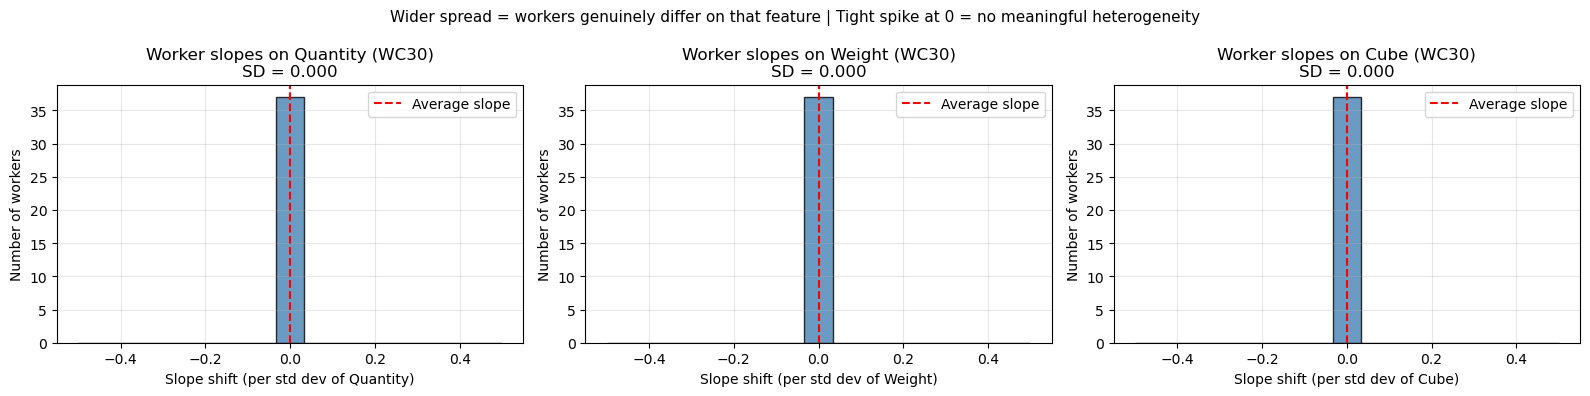

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, sv in zip(axes, SLOPE_CANDIDATES):
    col  = f"worker_slope_{sv.lower()}"
    data = slope_dist_data.get((sv, "30"))
    if data is None or col not in data.columns:
        ax.set_title(f"{sv} — no data")
        continue
    slope_sd = data[col].std()
    ax.hist(data[col], bins=15, edgecolor="black", color="steelblue", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Average slope")
    ax.set_title(f"Worker slopes on {sv} (WC30)\nSD = {slope_sd:.3f}")
    ax.set_xlabel(f"Slope shift (per std dev of {sv})")
    ax.set_ylabel("Number of workers")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Wider spread = workers genuinely differ on that feature | "
    "Tight spike at 0 = no meaningful heterogeneity",
    fontsize=11
)
plt.tight_layout()
plt.show()


## ShiftDuration Diagnostic — Do Workers Differ in Fatigue?

This section directly addresses the teacher's suggestion:
*'Try a random slope effects model looking into the duration of the shifts'*

ShiftDuration = hours elapsed since a worker's first pick of the day.
It is computed from training timestamps and used **only** in the mixed model here —
it is NOT added to XGBoost since timestamps aren't available at prediction time.

**The question:** do workers differ in how much they slow down over their shift?
- Slope SD ≈ 0 → fatigue progression is uniform across workers (or absent)
- Slope SD > 0 → some workers fatigue faster than others

Run on WC30 training data — most picks, most reliable estimates.

WC30 training rows: 58434
Shift duration range: 0.00h to 19.21h
Mean shift duration: 4.45h

    [ShiftDuration slope] Fixed effect: 0.996s per SD | Slope SD across workers: 0.000

Slope SD across workers: 0.000
Interpretation:
  Slope SD ≈ 0 — workers do not differ meaningfully in fatigue progression.
  The random intercept model is sufficient.


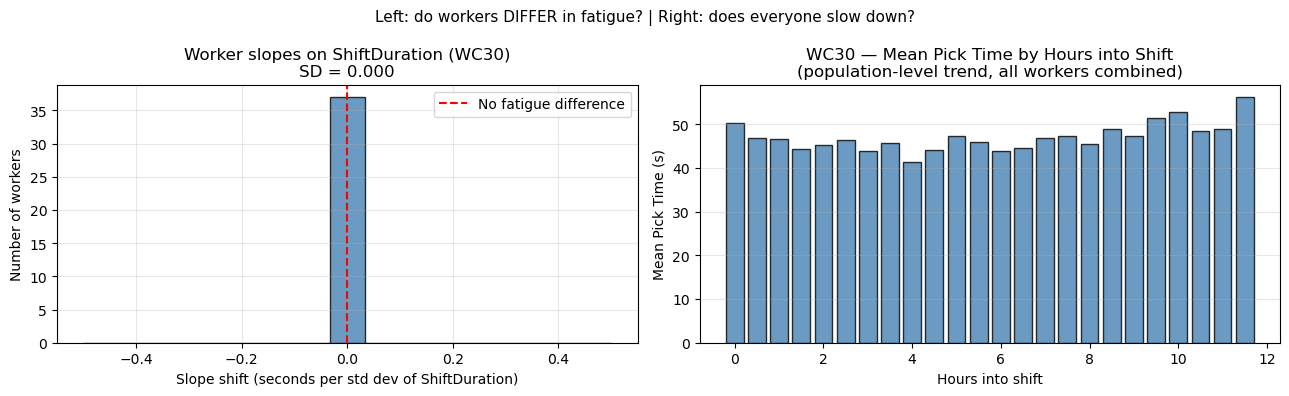

In [35]:
# Load WC30 training data — most data, most reliable estimates
df_wc30, _, _ = load_engineered_data(WAREHOUSE, "30", MAX_TIME)
train30, _    = split_by_days(df_wc30)

print(f"WC30 training rows: {len(train30)}")
print(f"Shift duration range: {train30['ShiftDuration'].min():.2f}h "
      f"to {train30['ShiftDuration'].max():.2f}h")
print(f"Mean shift duration: {train30['ShiftDuration'].mean():.2f}h\n")

# Fit random slope on ShiftDuration
# This is purely diagnostic — ShiftDuration is NOT used in XGBoost
slopes_shift = estimate_random_slopes(train30, "ShiftDuration")
slope_col    = "worker_slope_shiftduration"

slope_sd = slopes_shift[slope_col].std() if slope_col in slopes_shift.columns else 0.0

print(f"\nSlope SD across workers: {slope_sd:.3f}")
print("Interpretation:")
if slope_sd < 0.5:
    print("  Slope SD ≈ 0 — workers do not differ meaningfully in fatigue progression.")
    print("  The random intercept model is sufficient.")
else:
    print("  Slope SD > 0 — workers differ in how much they slow down over their shift.")
    print("  Some workers fatigue faster than others.")

# Plot slope distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: slope distribution
if slope_col in slopes_shift.columns:
    axes[0].hist(slopes_shift[slope_col], bins=15,
                 edgecolor="black", color="steelblue", alpha=0.8)
    axes[0].axvline(0, color="red", linestyle="--",
                    linewidth=1.5, label="No fatigue difference")
    axes[0].set_title(f"Worker slopes on ShiftDuration (WC30)\nSD = {slope_sd:.3f}")
    axes[0].set_xlabel("Slope shift (seconds per std dev of ShiftDuration)")
    axes[0].set_ylabel("Number of workers")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Right: mean pick time by shift hour — population-level fatigue trend
# (even if workers don't DIFFER in fatigue, everyone may slow down)
train30["shift_hour_bin"] = (train30["ShiftDuration"] // 0.5) * 0.5  # 30-min bins
shift_means = (
    train30.groupby("shift_hour_bin")["Time_Delta_sec"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "Mean pick time (s)", "count": "N picks"})
)
# Only show bins with enough picks
shift_means = shift_means[shift_means["N picks"] > 50]

axes[1].bar(shift_means["shift_hour_bin"], shift_means["Mean pick time (s)"],
            width=0.4, color="steelblue", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Hours into shift")
axes[1].set_ylabel("Mean Pick Time (s)")
axes[1].set_title("WC30 — Mean Pick Time by Hours into Shift\n"
                  "(population-level trend, all workers combined)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Left: do workers DIFFER in fatigue? | Right: does everyone slow down?",
    fontsize=11
)
plt.tight_layout()
plt.show()


## Actual vs Predicted — Best Slope Model per WorkCode (WC20 & WC30)

    [Quantity slope] Failed (Singular matrix) — using intercept only


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


    [Intercept] Grand mean: 39.2s | Worker SD: 11.1s | ICC: 0.034
    [Weight slope] Fixed effect: -0.562s per SD | Slope SD across workers: 0.000


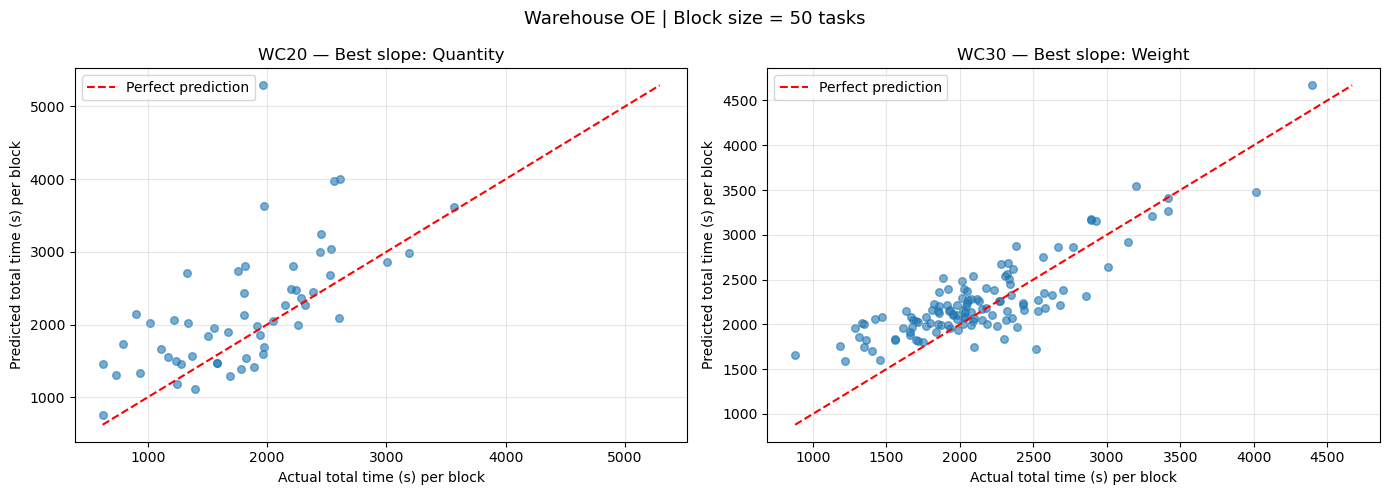

In [36]:
# Re-fit and predict using the best slope candidate per WorkCode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, wc in zip(axes, ["20", "30"]):
    sub    = summary_df[summary_df["WorkCode"] == wc]
    sv     = sub.loc[sub["MAE/task + Slope (s)"].idxmin(), "Slope"]
    slope_col = f"worker_slope_{sv.lower()}"

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df = split_by_days(df_wc)

    slopes_df = estimate_random_slopes(train_df, sv)
    train_df  = train_df.merge(slopes_df, on="UserID", how="left")
    test_df   = test_df.merge(slopes_df,  on="UserID", how="left")
    for col in ["worker_intercept", slope_col]:
        train_df[col] = train_df[col].fillna(0.0)
        test_df[col]  = test_df[col].fillna(0.0)
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    cats_clean  = [c for c in cat_cols  if c != "efficient_user"]
    feats_clean = [f for f in features  if f != "efficient_user"]
    feats_plot  = feats_clean + ["worker_intercept", slope_col]

    X_train, X_test = make_X(train_df, test_df, feats_plot, cats_clean)
    model  = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds  = pd.Series(model.predict(X_test), index=test_df.index)
    blocks = make_test_blocks(test_df, block_size=BLOCK_SIZE)

    actual_b = [y_test.loc[b["indices"]].sum() for b in blocks]
    pred_b   = [preds.loc[b["indices"]].sum()   for b in blocks]

    ax.scatter(actual_b, pred_b, alpha=0.6, s=30)
    lims = [min(min(actual_b), min(pred_b)), max(max(actual_b), max(pred_b))]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual total time (s) per block")
    ax.set_ylabel("Predicted total time (s) per block")
    ax.set_title(f"WC{wc} — Best slope: {sv}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Warehouse {WAREHOUSE} | Block size = {BLOCK_SIZE} tasks", fontsize=13)
plt.tight_layout()
plt.show()

In [37]:
df_wc.columns

Index(['ActivityCode', 'UserID', 'WorkCode', 'AssignmentID', 'ProductID', 'Quantity', 'Timestamp', 'LocationID', 'Prev_Timestamp', 'Prev_LocationID', 'Time_Delta_sec', 'ProductCode', 'UnitOfMeasure',
       'Weight', 'Cube', 'Aisle', 'Bay', 'Level', 'Slot', 'Prev_Aisle', 'Prev_Bay', 'Prev_Level', 'Prev_Slot', 'Aisle2', 'Bay2', 'Prev_Aisle2', 'Prev_Bay2', 'LocKey', 'PrevLocKey', 'Travel_Distance',
       'Aisle_group', 'Level_group', 'hour', 'time_of_day', 'UOM_group', 'day_of_week', 'same_aisle', 'same_lockey', 'diff_level', 'top_100_product', 'date', 'ShiftDuration'],
      dtype='object')

In [40]:
import pandas as pd
pd.set_option("display.max_colwidth", None)

slope_summary = pd.DataFrame({
    "Slope Variable": [
        "Quantity",
        "Weight", 
        "Cube",
        "Hour of Day",
        "ShiftDuration"
    ],
    "What it captures": [
        "Do some workers handle multi-unit picks better?",
        "Do stronger workers slow down less on heavy items?",
        "Do some workers handle bulky items differently?",
        "Do some workers fatigue faster by clock time?",
        "Do some workers slow down more over their shift?"
    ],
    "Slope SD": [0.000, 0.000, 0.000, 0.000, 0.000]
})

display(slope_summary)

,Slope Variable,What it captures,Slope SD
0,Quantity,Do some workers handle multi-unit picks better?,0.0
1,Weight,Do stronger workers slow down less on heavy items?,0.0
2,Cube,Do some workers handle bulky items differently?,0.0
3,Hour of Day,Do some workers fatigue faster by clock time?,0.0
4,ShiftDuration,Do some workers slow down more over their shift?,0.0
